In [27]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px

from scipy import stats

import seaborn as sns
sns.set_theme(style="whitegrid")

In [28]:
# import os

# print(os.getcwd())

In [ ]:
churn_data = pd.read_csv(r"D:\Churn_Prediction\data\raw_data\test_datafile.csv")
churn_data.head()

,customer_id,age,gender,tenure_months,contract_type,monthly_charges,total_charges,internet_service,phone_service,avg_monthly_gb_used,num_support_tickets,avg_monthly_minutes,satisfaction_score,payment_method,num_additional_services,last_interaction_date,churned
0,TC-004711,32.874739,Male,10.149619,Month-to-month,69.24,656.42,DSL,Yes,11.70,4.0,324.0,7.8,bank transfer,2,2024-06-14,1
1,TC-000692,59.389947,Female,3.446551,Month-to-month,98.48,251.15,DSL,no,9.46,1.0,306.8,6.0,Electronic check,5,2024-06-23,1
2,TC-000066,62.343600,male,1.386582,Two year,94.35,120.78,Fiber optic,Yes,9.56,4.0,349.5,5.5,Bank transfer,0,2024-06-21,0
3,TC-003427,45.788533,Female,67.609659,Month-to-month,85.87,5834.73,Fiber optic,yes,3.15,1.0,258.2,4.7,Credit card,4,2024-06-21,1
4,TC-004821,39.625418,F,27.319623,One year,62.14,1626.23,DSL,Yes,28.80,0.0,335.8,12.3,Credit card,2,2024-06-19,0


In [30]:
print("\nDataFrame Shape:")
print(churn_data.shape)

print("\nDataFrame Info:")
# churn_data.info() 
churn_data.info(verbose = True) 


DataFrame Shape:
(5050, 17)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              5050 non-null   object 
 1   age                      5040 non-null   float64
 2   gender                   5000 non-null   object 
 3   tenure_months            5039 non-null   float64
 4   contract_type            5050 non-null   object 
 5   monthly_charges          5038 non-null   float64
 6   total_charges            5027 non-null   float64
 7   internet_service         4545 non-null   object 
 8   phone_service            5050 non-null   object 
 9   avg_monthly_gb_used      5035 non-null   float64
 10  num_support_tickets      5050 non-null   float64
 11  avg_monthly_minutes      4968 non-null   float64
 12  satisfaction_score       5030 non-null   float64
 13  payment_method           5020 no

In [31]:
churn_data.columns.values

array(['customer_id', 'age', 'gender', 'tenure_months', 'contract_type',
       'monthly_charges', 'total_charges', 'internet_service',
       'phone_service', 'avg_monthly_gb_used', 'num_support_tickets',
       'avg_monthly_minutes', 'satisfaction_score', 'payment_method',
       'num_additional_services', 'last_interaction_date', 'churned'],
      dtype=object)

In [32]:
# Checking the data types of all the columns
print("\nData Types of All Columns:")
print(churn_data.dtypes)


Data Types of All Columns:
customer_id                 object
age                        float64
gender                      object
tenure_months              float64
contract_type               object
monthly_charges            float64
total_charges              float64
internet_service            object
phone_service               object
avg_monthly_gb_used        float64
num_support_tickets        float64
avg_monthly_minutes        float64
satisfaction_score         float64
payment_method              object
num_additional_services      int64
last_interaction_date       object
churned                      int64
dtype: object


In [33]:
# Descriptive statistics of numeric variables
print("\nDataFrame Description:")
churn_data.describe().T


DataFrame Description:


,count,mean,std,min,25%,50%,75%,max
age,5040.0,42.752631,24.003502,-1.00000,31.978442,42.193729,52.026286,999.00
tenure_months,5039.0,24.092848,24.343918,-12.00000,6.837390,16.483189,33.823095,500.00
monthly_charges,5038.0,69.921683,211.202935,-50.00000,47.532500,65.050000,82.250000,9999.00
total_charges,5027.0,1642.319540,4183.374844,0.66000,372.280000,953.640000,2122.525000,218681.58
avg_monthly_gb_used,5035.0,15.153484,15.601767,-86.55345,4.425000,10.360000,21.625000,119.67
num_support_tickets,5050.0,2.270099,12.218691,-5.00000,1.000000,2.000000,3.000000,500.00
avg_monthly_minutes,4968.0,299.333394,117.937511,0.00000,215.400000,299.250000,378.225000,747.50
satisfaction_score,5030.0,6.098708,3.333432,-1.40000,4.600000,6.000000,7.400000,99.00
num_additional_services,5050.0,2.483366,1.711466,0.00000,1.000000,2.000000,4.000000,5.00
churned,5050.0,0.363762,0.481129,0.00000,0.000000,0.000000,1.000000,1.00


Text(0.5, 1.02, 'Count of TARGET Variable per category')

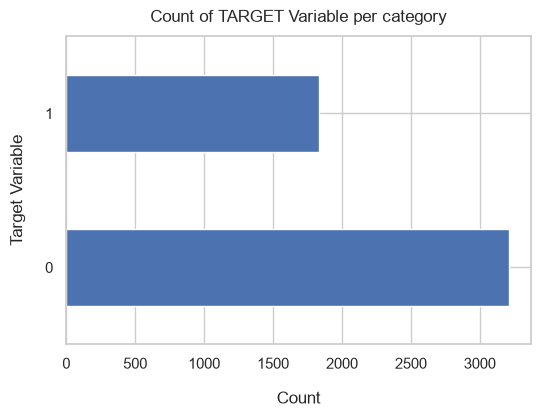

In [34]:
churn_data['churned'].value_counts().plot(kind='barh', figsize=(6, 4))
plt.xlabel("Count", labelpad=14)
plt.ylabel("Target Variable", labelpad=14)
plt.title("Count of TARGET Variable per category", y=1.02)

In [35]:
print(churn_data['churned'].value_counts())

100*churn_data['churned'].value_counts()/len(churn_data['churned'])

churned
0    3213
1    1837
Name: count, dtype: int64


churned
0    63.623762
1    36.376238
Name: count, dtype: float64

Data is highly imbalanced, `ratio = 63:36`

So we analyse the data with other features while taking the target values separately to get some insights.

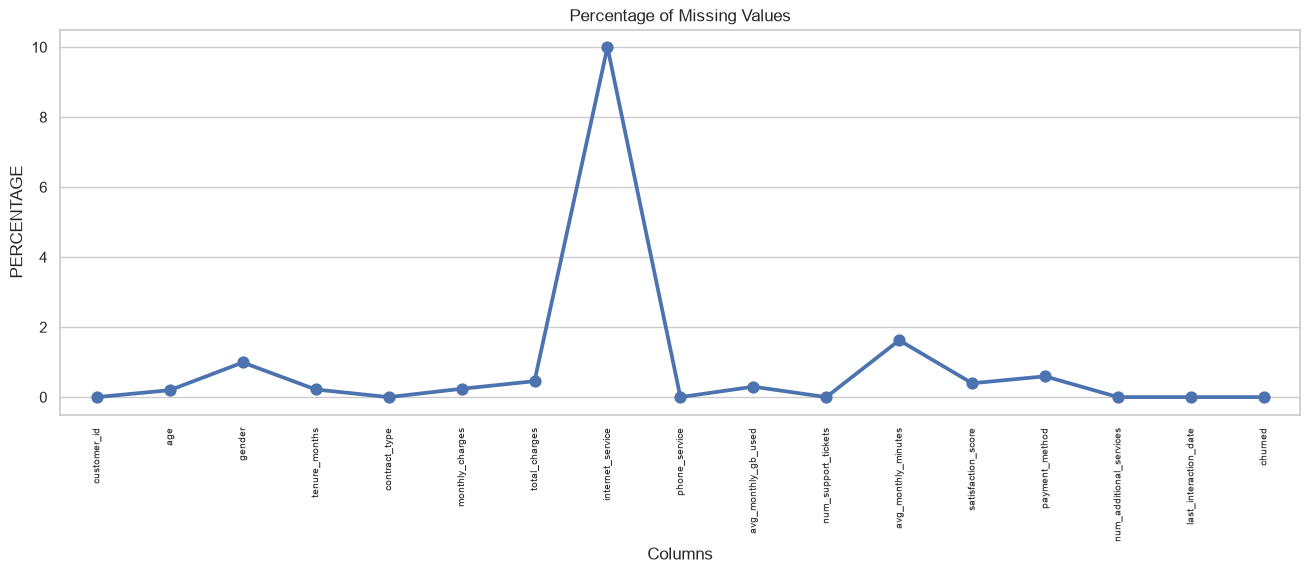

In [36]:
missing = pd.DataFrame((churn_data.isnull().sum()) * 100 / churn_data.shape[0]).reset_index()

plt.figure(figsize=(16,5))

ax = sns.pointplot(x='index', y=0, data=missing)

plt.xticks(rotation=90, fontsize=7)
plt.title("Percentage of Missing Values")
plt.ylabel("PERCENTAGE")
plt.xlabel("Columns")
plt.show()

In [37]:
# churn_data.isnull().sum()


missing = (
    churn_data.isna()
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

missing.columns = ["Column", "Missing Count"]

missing["Percentage"] = (
    missing["Missing Count"] / len(churn_data)
) * 100

# # Show only columns with missing values
missing = missing[missing["Missing Count"] > 0]

missing

,Column,Missing Count,Percentage
0,internet_service,505,10.000000
1,avg_monthly_minutes,82,1.623762
2,gender,50,0.990099
3,payment_method,30,0.594059
4,total_charges,23,0.455446
5,satisfaction_score,20,0.396040
6,avg_monthly_gb_used,15,0.297030
7,monthly_charges,12,0.237624
8,tenure_months,11,0.217822
9,age,10,0.198020


In [38]:
missing_columns = missing["Column"].tolist()

# for col in missing_columns:
#     null_customers = df.loc[df[col].isna(), "customer_id"]
    
#     print(f"\n{col} missing customer_ids:")
#     print(null_customers.tolist())


for col in missing_columns:
    missing_count = churn_data[col].isna().sum()
    print(f"\n{col} - Missing count: {missing_count}")
    display(churn_data[churn_data[col].isna()].head(5))


internet_service - Missing count: 505


,customer_id,age,gender,tenure_months,contract_type,monthly_charges,total_charges,internet_service,phone_service,avg_monthly_gb_used,num_support_tickets,avg_monthly_minutes,satisfaction_score,payment_method,num_additional_services,last_interaction_date,churned
17,TC-000180,82.802537,Female,14.781602,Month-to-month,69.23,880.21,NaN,No,21.70000,3.0,504.8,6.5,Bank transfer,3,2024-06-04,1
23,TC-000034,26.134336,F,32.231280,One year,109.36,3561.35,NaN,No,-86.55345,3.0,277.7,4.2,credit card,3,2024-06-21,0
26,TC-000486,20.666194,Female,58.450019,Two year,74.97,4516.36,NaN,Yes,40.41000,1.0,457.5,6.2,Bank transfer,4,2024-05-27,0
27,TC-000080,18.000000,Male,5.225232,Month-to-month,57.52,527.38,NaN,Yes,29.03000,0.0,266.9,5.8,Credit card,5,2024-05-11,0
37,TC-003244,57.880928,male,17.284485,Month-to-month,52.77,802.64,NaN,Yes,34.09000,3.0,317.1,6.2,Mailed check,0,2024-06-09,0



avg_monthly_minutes - Missing count: 82


,customer_id,age,gender,tenure_months,contract_type,monthly_charges,total_charges,internet_service,phone_service,avg_monthly_gb_used,num_support_tickets,avg_monthly_minutes,satisfaction_score,payment_method,num_additional_services,last_interaction_date,churned
14,TC-004302,21.515739,F,8.862193,Two year,20.88,101.19,Fiber optic,N,0.58,4.0,NaN,0.6,Electronic check,0,2024-06-13,0
35,TC-003735,53.897635,female,88.233410,One year,50.35,4276.91,No,Y,36.97,1.0,NaN,NaN,Bank transfer,1,2024-06-19,0
85,TC-000765,59.239100,Female,4.539551,Month-to-month,71.57,378.56,DSL,Yes,14.38,2.0,NaN,7.9,Electronic check,0,2024-05-26,0
90,TC-002581,47.581582,female,3.739508,Month-to-month,106.71,641.06,DSL,Y,5.83,3.0,NaN,7.7,Electronic check,1,2024-06-20,1
168,TC-004041,45.071383,Female,28.240633,One year,15.00,475.26,Fiber optic,Yes,0.38,0.0,NaN,9.2,Credit card,5,2024-05-04,0



gender - Missing count: 50


...

,customer_id,age,gender,tenure_months,contract_type,monthly_charges,total_charges,internet_service,phone_service,avg_monthly_gb_used,num_support_tickets,avg_monthly_minutes,satisfaction_score,payment_method,num_additional_services,last_interaction_date,churned
118,TC-002686,46.742339,Male,5.010372,Month-to-month,NaN,NaN,DSL,Yes,17.81,0.0,193.1,4.8,Bank transfer,5,2024-05-14,0
122,TC-003131,40.661488,Male,33.033863,One year,NaN,NaN,DSL,Y,41.42,3.0,434.4,6.4,Mailed check,5,2024-06-27,1
309,TC-004032,20.756594,Female,26.395624,One year,NaN,NaN,Fiber optic,No,7.57,1.0,145.7,9.6,Credit card,0,2024-04-22,0
2198,TC-002868,28.699786,Male,3.717042,Month-to-month,NaN,NaN,Fiber optic,Yes,11.73,1.0,388.5,4.3,Electronic check,2,2024-05-15,0
2453,TC-001038,20.034377,Female,15.885032,Month-to-month,NaN,NaN,DSL,No,1.61,4.0,118.7,7.7,Electronic check,1,2024-06-23,1



tenure_months - Missing count: 11


,customer_id,age,gender,tenure_months,contract_type,monthly_charges,total_charges,internet_service,phone_service,avg_monthly_gb_used,num_support_tickets,avg_monthly_minutes,satisfaction_score,payment_method,num_additional_services,last_interaction_date,churned
510,TC-001225,39.220685,Male,NaN,Month-to-month,67.78,NaN,Fiber optic,No,18.95,2.0,172.0,5.8,bank transfer,5,2024-06-23,1
1472,TC-003193,76.224778,Male,NaN,Month-to-month,55.29,NaN,DSL,yes,25.68,0.0,248.8,2.0,Bank transfer,5,2024-06-25,0
1634,TC-004449,0.000000,Female,NaN,Month-to-month,102.32,NaN,Fiber optic,no,5.31,1.0,182.8,4.7,Electronic check,3,2024-06-28,1
1704,TC-000866,36.184477,female,NaN,Two year,48.95,NaN,No,yes,37.81,2.0,400.5,8.1,Credit card,0,2024-06-14,0
2729,TC-001677,60.257378,Female,NaN,Month-to-month,43.99,NaN,Fiber optic,Yes,8.00,3.0,244.7,6.1,BT,2,2024-06-21,1



age - Missing count: 10


,customer_id,age,gender,tenure_months,contract_type,monthly_charges,total_charges,internet_service,phone_service,avg_monthly_gb_used,num_support_tickets,avg_monthly_minutes,satisfaction_score,payment_method,num_additional_services,last_interaction_date,churned
30,TC-001176,NaN,male,15.361868,Month-to-month,20.00,328.64,Fiber optic,Y,14.02,1.0,172.1,10.3,Bank transfer,1,2024-04-25,0
1062,TC-001768,NaN,Male,10.695504,Month-to-month,51.93,503.12,dsl,no,15.25,6.0,366.1,6.1,Credit card,2,2024-06-14,0
1334,TC-004279,NaN,F,18.436240,Month-to-month,51.02,884.46,Fiber optic,Yes,4.13,2.0,466.6,3.9,Electronic check,5,2024-06-27,1
1519,TC-000726,NaN,Male,3.747368,Two year,95.56,333.43,NaN,No,31.27,0.0,398.0,2.5,Credit card,4,2024-06-22,1
1872,TC-000258,NaN,Male,2.837563,Month-to-month,101.27,301.69,Fiber optic,yes,0.47,2.0,574.5,-0.5,BT,2,2024-06-03,1


In [39]:
churn_data.loc[churn_data ['internet_service'].isnull() == True]

,customer_id,age,gender,tenure_months,contract_type,monthly_charges,total_charges,internet_service,phone_service,avg_monthly_gb_used,num_support_tickets,avg_monthly_minutes,satisfaction_score,payment_method,num_additional_services,last_interaction_date,churned
17,TC-000180,82.802537,Female,14.781602,Month-to-month,69.23,880.21,NaN,No,21.70000,3.0,504.8,6.5,Bank transfer,3,2024-06-04,1
23,TC-000034,26.134336,F,32.231280,One year,109.36,3561.35,NaN,No,-86.55345,3.0,277.7,4.2,credit card,3,2024-06-21,0
26,TC-000486,20.666194,Female,58.450019,Two year,74.97,4516.36,NaN,Yes,40.41000,1.0,457.5,6.2,Bank transfer,4,2024-05-27,0
27,TC-000080,18.000000,Male,5.225232,Month-to-month,57.52,527.38,NaN,Yes,29.03000,0.0,266.9,5.8,Credit card,5,2024-05-11,0
37,TC-003244,57.880928,male,17.284485,Month-to-month,52.77,802.64,NaN,Yes,34.09000,3.0,317.1,6.2,Mailed check,0,2024-06-09,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4978,TC-001276,44.125754,F,11.750119,One year,25.96,176.10,NaN,no,16.46000,2.0,411.6,3.9,Credit card,0,2024-06-29,0
4999,TC-004015,40.813990,Female,6.811363,Month-to-month,54.26,484.87,NaN,No,2.05000,3.0,429.8,4.9,Bank transfer,0,2024-06-29,1
5009,TC-002364,58.690326,M,56.666345,Month-to-month,30.36,1690.09,NaN,Yes,3.74000,1.0,390.3,6.7,Credit card,4,2024-06-26,1
5010,TC-000601,53.354829,Male,17.251513,Two year,40.53,725.38,NaN,Yes,6.76000,1.0,197.4,6.5,Mailed check,5,2024-05-12,0


In [40]:
churn_data['internet_service'].isna().sum()

np.int64(505)

In [41]:
# print("\nGender:")
# print(churn_data['gender'].value_counts())

print("\nInternet Service:")
print(churn_data['internet_service'].value_counts())

# print("\nPhone Service:")
# print(churn_data['phone_service'].value_counts())

# print("\nPayment Method:")
# print(churn_data['payment_method'].value_counts())

# print("\nContract Type:")
# print(churn_data['contract_type'].value_counts())


Internet Service:
internet_service
Fiber optic    1721
DSL            1278
No              736
fiber           440
dsl             370
Name: count, dtype: int64


In [42]:
churn_data['internet_service'].isna().sum()

np.int64(505)

In [43]:
# ==============================
# Data Standardization
# ==============================

# Gender standardization
churn_data['gender'] = (
    churn_data['gender']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'male': 'Male',
        'm': 'Male',
        'female': 'Female',
        'f': 'Female',
        'other': 'Other'
    })
)

# Internet service standardization
churn_data['internet_service'] = (
    churn_data['internet_service']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'fiber optic': 'Fiber optic',
        'fiber': 'Fiber',
        'dsl': 'DSL',
        'no': 'No'
    })
)

# Phone service standardization
churn_data['phone_service'] = (
    churn_data['phone_service']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'yes': 'Yes',
        'y': 'Yes',
        'no': 'No',
        'n': 'No'
    })
)

# Payment method standardization
churn_data['payment_method'] = (
    churn_data['payment_method']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'credit card': 'Credit card',
        'cc': 'Credit card',
        'bank transfer': 'Bank transfer',
        'bt': 'Bank transfer',
        'electronic check': 'Electronic check',
        'mailed check': 'Mailed check'
    })
)

# Contract type standardization
churn_data['contract_type'] = ( 
    churn_data['contract_type']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'month-to-month': 'Month-to-month',
        'one year': 'One year',
        'two year': 'Two year'
    })
)

In [44]:
# print("\nGender:")
# print(churn_data['gender'].value_counts())

print("\nInternet Service:")
print(churn_data['internet_service'].value_counts())

# print("\nPhone Service:")
# print(churn_data['phone_service'].value_counts())

# print("\nPayment Method:")
# print(churn_data['payment_method'].value_counts())

# print("\nContract Type:")
# print(churn_data['contract_type'].value_counts())


Internet Service:
internet_service
Fiber optic    1721
DSL            1648
No              736
nan             505
Fiber           440
Name: count, dtype: int64


In [45]:
churn_data.head(10)

,customer_id,age,gender,tenure_months,contract_type,monthly_charges,total_charges,internet_service,phone_service,avg_monthly_gb_used,num_support_tickets,avg_monthly_minutes,satisfaction_score,payment_method,num_additional_services,last_interaction_date,churned
0,TC-004711,32.874739,Male,10.149619,Month-to-month,69.24,656.42,DSL,Yes,11.70,4.0,324.0,7.8,Bank transfer,2,2024-06-14,1
1,TC-000692,59.389947,Female,3.446551,Month-to-month,98.48,251.15,DSL,No,9.46,1.0,306.8,6.0,Electronic check,5,2024-06-23,1
2,TC-000066,62.343600,Male,1.386582,Two year,94.35,120.78,Fiber optic,Yes,9.56,4.0,349.5,5.5,Bank transfer,0,2024-06-21,0
3,TC-003427,45.788533,Female,67.609659,Month-to-month,85.87,5834.73,Fiber optic,Yes,3.15,1.0,258.2,4.7,Credit card,4,2024-06-21,1
4,TC-004821,39.625418,Female,27.319623,One year,62.14,1626.23,DSL,Yes,28.80,0.0,335.8,12.3,Credit card,2,2024-06-19,0
5,TC-000394,69.471881,Male,71.080591,Month-to-month,50.90,77.11,No,Yes,7.31,4.0,282.7,5.2,Credit card,5,2024-05-28,0
6,TC-001425,26.327862,Male,25.963791,Month-to-month,84.25,2293.74,DSL,Yes,0.47,1.0,335.6,2.3,Credit card,5,2024-06-11,1
7,TC-000643,38.106130,Female,37.518907,Month-to-month,99.26,3624.68,Fiber optic,Yes,19.43,6.0,410.6,5.4,Mailed check,2,2024-06-19,0
8,TC-002836,37.502427,Female,3.589713,Month-to-month,106.82,289.30,No,No,7.75,1.0,361.7,7.4,Credit card,3,2024-06-25,0
9,TC-001739,56.254614,Male,7.402492,Month-to-month,84.02,547.54,Fiber,Yes,54.48,1.0,370.8,4.9,Bank transfer,3,2024-06-30,1


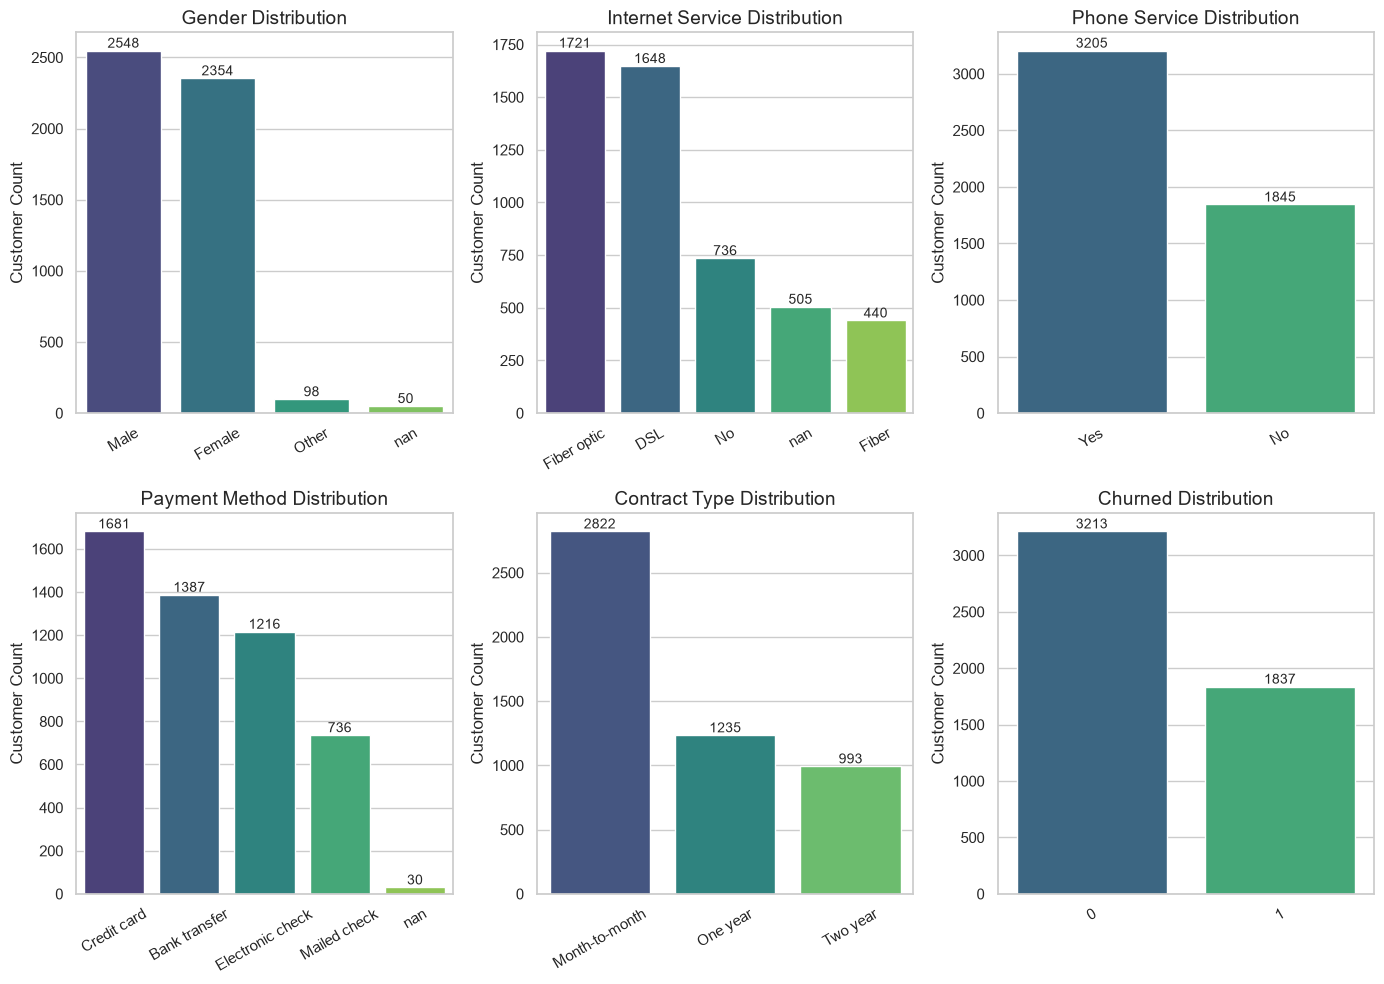

In [46]:
cols = ['gender', 'internet_service', 'phone_service', 'payment_method', 'contract_type', 'churned']

fig, axes = plt.subplots(2, 3, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    order = churn_data[col].value_counts().index
    
    sns.countplot(
        data=churn_data,
        x=col,
        order=order,
        palette="viridis",
        ax=ax
    )
    
    ax.set_title(f"{col.replace('_', ' ').title()} Distribution", fontsize=14)
    ax.set_xlabel("")
    ax.set_ylabel("Customer Count")
    ax.tick_params(axis='x', rotation=30)
    
    # Add count labels
    for container in ax.containers:
        ax.bar_label(container, fontsize=10)

plt.tight_layout()
plt.show()

In [47]:
# Display duplicate rows based on customer_id
duplicate_rows = df[df.duplicated(subset=["customer_id"], keep=False)]

print("\nDuplicate customer IDs:")
duplicate_rows

NameError: name 'df' is not defined

In [ ]:
# Count duplicate customer IDs 
duplicates = df.duplicated(subset=["customer_id"]).sum()
print(f"Number of duplicate customer IDs: {duplicates}")

In [ ]:
duplicate_rows[duplicate_rows["customer_id"] == "TC-001145"]

duplicate_rows[duplicate_rows["customer_id"] == "TC-004711"]

In [ ]:
# Find duplicate records based on customer_id + contract_type + monthly_charges
duplicate_rows = df[
    df.duplicated(
        subset=["customer_id", "contract_type", "monthly_charges"],
        keep=False
    )
]

print(f"Number of duplicate rows: {len(duplicate_rows)}")

duplicate_rows

In [ ]:
customer_connections = (
    df.groupby("customer_id")
      .agg(
          total_connections=("customer_id", "count"),
          unique_contracts=("contract_type", "nunique"),
          unique_monthly_charges=("monthly_charges", "nunique"),
          unique_internet_services=("internet_service", "nunique"),
          unique_phone_services=("phone_service", "nunique"),
          unique_total_charges=("total_charges", "nunique")
      )
      .reset_index()
)

# Customers with multiple connections (different service/contract details)
real_multiple_connections = customer_connections.query(
    "total_connections > 1 and "
    "(unique_contracts > 1 or "
    "unique_monthly_charges > 1 or "
    "unique_internet_services > 1 or "
    "unique_phone_services > 1 or "
    "unique_total_charges > 1)"
)

real_multiple_connections

count = len(real_multiple_connections)

print(f"Number of customers with multiple connections: {count}")

In [ ]:
# df = df.drop_duplicates(
#     subset=["customer_id"],
#     keep="first"
# )


# print("Dataset shape after removing duplicates:", df.shape)

# print(
#     "Remaining duplicate customer IDs:",
#     df.duplicated(subset=["customer_id"]).sum()
# )



# Convert last_interaction_date to datetime
df["last_interaction_date"] = pd.to_datetime(df["last_interaction_date"])

# Sort by customer and keep the latest interaction record
df = df.sort_values(
    by=["customer_id", "last_interaction_date"],
    ascending=[True, False]
)

# Remove duplicate customers, keeping the most recent record
df = df.drop_duplicates(
    subset=["customer_id"],
    keep="first"
)

print("Dataset shape after removing duplicates:", df.shape)

print(
    "Remaining duplicate customer IDs:",
    df.duplicated(subset=["customer_id"]).sum()
)

In [ ]:
df.head()

In [ ]:
print("\nInternet Service:")
print(df['internet_service'].value_counts())

In [ ]:
df = df.replace('nan', np.nan)

In [ ]:
missing = (
    churn_data.isna()
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

missing.columns = ["Column", "Missing Count"]

missing["Percentage"] = (
    missing["Missing Count"] / len(df)
) * 100

# # Show only columns with missing values
missing = missing[missing["Missing Count"] > 0]

missing

In [ ]:
missing_columns = missing["Column"].tolist()

# for col in missing_columns:
#     null_customers = df.loc[df[col].isna(), "customer_id"]
    
#     print(f"\n{col} missing customer_ids:")
#     print(null_customers.tolist())


for col in missing_columns:
    missing_count = df[col].isna().sum()
    print(f"\n{col} - Missing count: {missing_count}")
    display(df[df[col].isna()].head(5))

In [ ]:
# Calculate skewness
skew_value = df.skew(numeric_only=True)

# Convert to DataFrame and sort
skew_df = skew_value.reset_index()
skew_df.columns = ['Column', 'Skewness']

# Sort by absolute skewness
skew_df['Abs_Skewness'] = skew_df['Skewness'].abs()
skew_df = skew_df.sort_values(by='Abs_Skewness', ascending=False)

print(skew_df)

In [ ]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

correlation = df[numeric_cols].corr()['churned'].sort_values(ascending=False)

print(correlation)

In [ ]:
missing_numeric = [
    'age',
    'tenure_months',
    'monthly_charges',
    'total_charges',
    'avg_monthly_gb_used',
    'satisfaction_score',
    'avg_monthly_minutes'
]

for col in missing_numeric:
    print(col, df[col].skew())

In [ ]:
df.describe(include="all").T

In [ ]:
df[df['age'] < 0]

In [ ]:
df[df['age'] > 100]

In [ ]:
df.loc[(df['age'] < 18) | (df['age'] > 100), 'age'] = np.nan

In [ ]:
df[df["age"].isna()].shape[0]

In [ ]:
print("monthly charges less than 0 customers:", df[df['monthly_charges'] < 0].shape[0])
print("monthly charges greater than 500 customers:", df[df['monthly_charges'] > 500].shape[0])

In [ ]:
df['monthly_charges'].describe(include="all").T

In [ ]:
df.loc[df['monthly_charges'] < 0, 'monthly_charges'] = np.nan
df.loc[df['monthly_charges'] > 500, 'monthly_charges'] = np.nan

In [ ]:
df['monthly_charges'].describe(include="all").T

In [ ]:
df['monthly_charges'].fillna(
    df['monthly_charges'].median(),
    inplace=True
)

df['monthly_charges'].isna().sum()

In [ ]:
print("tenure months less than 0 customers:", df[df['tenure_months'] < 0].shape[0])
print("tenure months greater than 120 customers:", df[df['tenure_months'] > 120].shape[0])

In [ ]:
df.loc[df['tenure_months'] < 0, 'tenure_months'] = np.nan

df.loc[df['tenure_months'] > 120, 'tenure_months'] = np.nan

In [ ]:
df['tenure_months'].describe(include="all").T

In [ ]:
df['tenure_months'].fillna(
    df['tenure_months'].median(),
    inplace=True
)

df['monthly_charges'].isna().sum()

In [ ]:
df['num_support_tickets'].describe(include="all").T

In [ ]:
print("num support tickets less than 0 customers:", df[df['num_support_tickets'] < 0].shape[0])
# print("num support tickets greater than 10 customers:", df[df['num_support_tickets'] > 10].shape[0])
# print("num support tickets greater than 20 customers:", df[df['num_support_tickets'] > 20].shape[0])
print("num support tickets greater than 50 customers:", df[df['num_support_tickets'] > 50].shape[0])

In [ ]:
df.loc[df['num_support_tickets'] < 0, 'num_support_tickets'] = np.nan

df.loc[df['num_support_tickets'] > 50, 'num_support_tickets'] = np.nan

In [ ]:
df['num_support_tickets'].describe(include="all").T

In [ ]:
df['num_support_tickets'].isna().sum()

In [ ]:
df['num_support_tickets'].skew()

In [ ]:
df['internet_service'].isna().sum()

In [ ]:
# Rows where internet_service is missing
df[df["internet_service"].isna()].head(5)

In [ ]:
# count = (
#     df["internet_service"].isna() &
#     (df["avg_monthly_gb_used"] > 0)
# ).sum()

# print("Missing internet_service with data usage:", count)


# Missing internet_service with usage
with_use = (
    df["internet_service"].isna() &
    (df["avg_monthly_gb_used"] > 0)
).sum()

# Missing internet_service without usage
without_use = (
    df["internet_service"].isna() &
    ((df["avg_monthly_gb_used"].isna()) | (df["avg_monthly_gb_used"] == 0))
).sum()

print("Missing internet_service with usage:", with_use)
print("Missing internet_service without usage:", without_use)

In [ ]:
missing_internet = df[df["internet_service"].isna()]
print(len(missing_internet))

print("Positive usage:",
      (missing_internet["avg_monthly_gb_used"] > 0).sum())

print("Zero usage:",
      (missing_internet["avg_monthly_gb_used"] == 0).sum())

print("Missing usage:",
      missing_internet["avg_monthly_gb_used"].isna().sum())

print("Negative usage:",
      (missing_internet["avg_monthly_gb_used"] < 0).sum())

In [ ]:
df["avg_monthly_gb_used"] = df["avg_monthly_gb_used"].abs()


# # Fix negative usage first
# df.loc[
#     df["avg_monthly_gb_used"] < 0,
#     "avg_monthly_gb_used"
# ] = np.nan

In [ ]:
df[df["internet_service"].isna()]["churned"].value_counts(normalize=True)

df[df["internet_service"].isna()]["churned"].value_counts()

In [ ]:
missing_churn = df[df["internet_service"].isna()]["churned"].mean()
overall_churn = df["churned"].mean()

print("Missing internet_service churn rate:", missing_churn)
print("Overall churn rate:", overall_churn)

In [ ]:
# Assign unknown category for missing internet service
df["internet_service"] = df["internet_service"].fillna("Unknown")

In [ ]:
# # Keep missing information
# df["internet_service_missing"] = df["internet_service"].isna()

# print("\nInternet Service:")
# print(df['internet_service'].value_counts())

In [ ]:
# Rows where avg_monthly_minutes is missing
df[df["avg_monthly_minutes"].isna()].head(10)

In [ ]:
# Calculate skewness
skew_value = df['avg_monthly_minutes'].skew()

print("Skewness:", skew_value)

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(8,5))
# sns.histplot(df['avg_monthly_minutes'], kde=True)
# plt.title("Distribution of Average Monthly Minutes")
# plt.xlabel("Avg Monthly Minutes")
# plt.show()

In [ ]:
# # Customers without phone service
# df.loc[df['phone_service'] == 'No', 'avg_monthly_minutes'] = (
#     df.loc[df['phone_service'] == 'No', 'avg_monthly_minutes'].fillna(0)
# )

# # Customers with phone service
# median_minutes = df.loc[df['phone_service'] == 'Yes', 'avg_monthly_minutes'].median()

# df.loc[df['phone_service'] == 'Yes', 'avg_monthly_minutes'] = (
#     df.loc[df['phone_service'] == 'Yes', 'avg_monthly_minutes'].fillna(median_minutes)
# )


# df[df['phone_service']=='No'][['customer_id','phone_service','avg_monthly_minutes']].sort_values(
#     'avg_monthly_minutes', ascending=False
# ).head(10)

In [ ]:
df['avg_monthly_minutes'] = df.groupby('phone_service')['avg_monthly_minutes'].transform(
    lambda x: x.fillna(x.median())
)

In [ ]:
df['avg_monthly_minutes'].isnull().sum()

In [ ]:
df.groupby('phone_service')['avg_monthly_minutes'].describe()

In [ ]:
# Calculate skewness
skew_value = df['avg_monthly_minutes'].skew()

print("Skewness:", skew_value)

In [ ]:
df['gender'].isnull().sum()

In [ ]:
# Rows where gender is missing
df[df["gender"].isna()].head(5)

In [ ]:
df['gender'] = df['gender'].fillna('Unknown')

In [ ]:
df['satisfaction_score'].head()

In [ ]:
df['satisfaction_score'].isnull().sum()

In [ ]:
df['satisfaction_score'].describe(include="all").T

In [ ]:
print("num customers with satisfaction score < 0:", df[df['satisfaction_score'] < 0].shape[0])
print("num customers with satisfaction score > 10:", df[df['satisfaction_score'] > 10].shape[0])

In [ ]:
df.loc[
    (df['satisfaction_score'] < 0) |
    (df['satisfaction_score'] > 10),
    'satisfaction_score'
] = np.nan

In [ ]:
df['satisfaction_score'].fillna(
    df['satisfaction_score'].median(),
    inplace=True
)

In [ ]:
df['satisfaction_score'].describe(include="all").T

In [ ]:
# df[(df['satisfaction_score'] > 10) & (df['satisfaction_score'] < 20)]

# df.loc[
#     (df['satisfaction_score'] > 10) & (df['satisfaction_score'] < 20)
# ].sort_values('satisfaction_score', ascending=False)

In [ ]:
df['avg_monthly_gb_used'].describe(include="all").T

In [ ]:
print("num customers with avg_monthly_gb_used < 0:", df[df['avg_monthly_gb_used'] < 0].shape[0])
print("num customers with avg_monthly_gb_used > 100:", df[df['avg_monthly_gb_used'] > 100].shape[0])

In [ ]:
df['avg_monthly_gb_used'].isna().sum()

In [ ]:
df['avg_monthly_gb_used'] = df['avg_monthly_gb_used'].fillna(
    df['avg_monthly_gb_used'].median()
)

In [ ]:
df.head()

In [ ]:
df.describe(include="all").T